In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split



Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\Aishwarya G Kumar\\.matplotlib\\fontlist-v390.json.matplotlib-lock'


In [2]:
# LOAD AND PREPARE DATA
train = pd.read_csv("train.csv")
features = pd.read_csv("features.csv")
stores = pd.read_csv("stores.csv")

# Merge everything
df = train.merge(features, on=['Store', 'Date', 'IsHoliday'], how='left').merge(stores, on='Store', how='left')
df['Date'] = pd.to_datetime(df['Date'])


In [3]:
#  FEATURE ENGINEERING
df['year'] = df['Date'].dt.year
df['week'] = df['Date'].dt.isocalendar().week.astype(int)
df['month'] = df['Date'].dt.month
for i in range(1, 6):
    df[f'MarkDown{i}'] = df[f'MarkDown{i}'].fillna(0)
df.fillna(0, inplace=True)
df = pd.get_dummies(df, columns=['Type'], drop_first=True)


In [4]:
# TRAIN/VALIDATION SPLIT
# We keep 'Date' in a separate variable to map back to predictions later
X = df.drop(['Weekly_Sales', 'Date'], axis=1)
y = df['Weekly_Sales']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


In [5]:

# TRAIN MODEL & PREDICT
model = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_val)

# 5. DATA ALIGNMENT FOR VISUALIZATION
# Re-attach dates to the validation results
comparison_df = pd.DataFrame({
    'Date': df.loc[y_val.index, 'Date'],
    'Actual_Sales': y_val.values,
    'Predicted_Sales': y_pred
})

# Aggregate by Date to show "Total Company Weekly Sales"
# This turns thousands of scattered points into 2 clean lines
comparison_trend = comparison_df.groupby('Date').sum().reset_index().sort_values('Date')


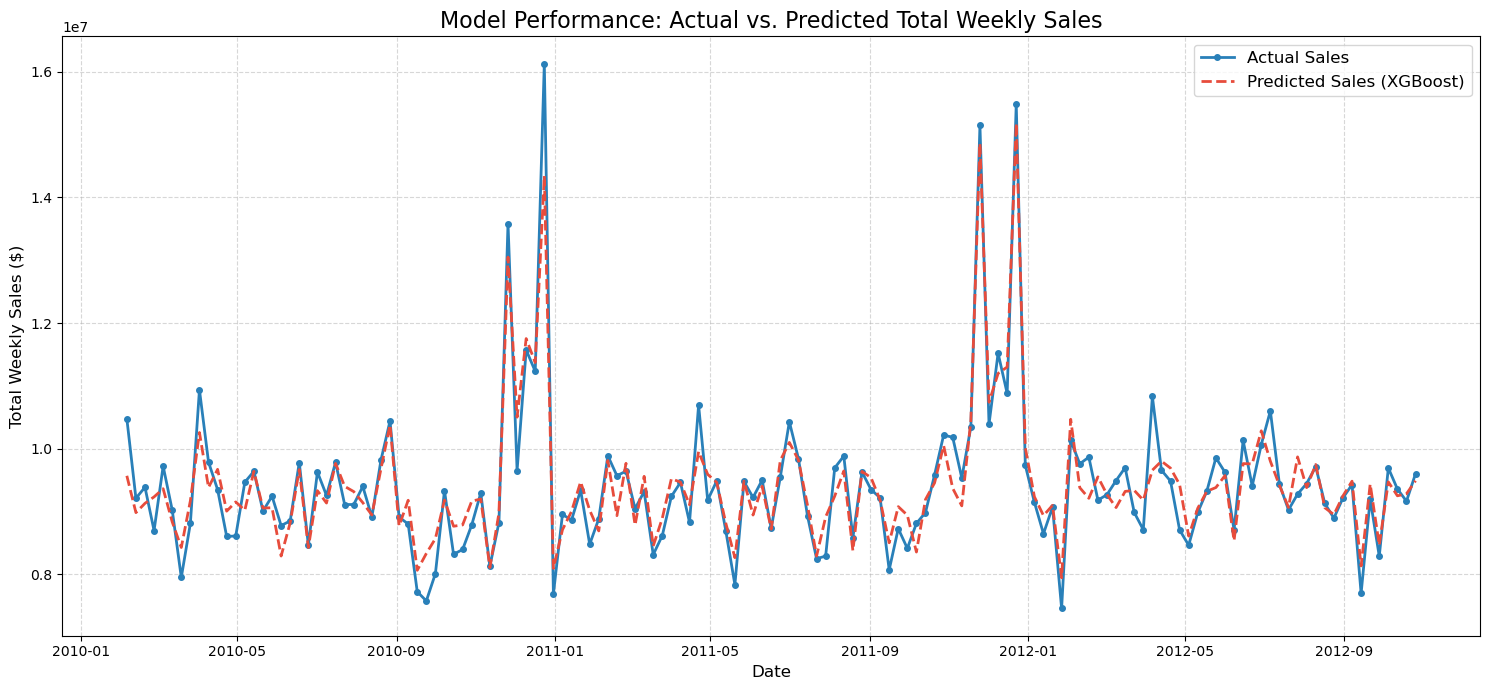

In [6]:
#  PLOT ACTUAL VS PREDICTED
plt.figure(figsize=(15, 7))

plt.plot(comparison_trend['Date'], comparison_trend['Actual_Sales'], 
         label='Actual Sales', color='#2980b9', linewidth=2, marker='o', markersize=4)

plt.plot(comparison_trend['Date'], comparison_trend['Predicted_Sales'], 
         label='Predicted Sales (XGBoost)', color='#e74c3c', linestyle='--', linewidth=2)

# Styling
plt.title("Model Performance: Actual vs. Predicted Total Weekly Sales", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Total Weekly Sales ($)", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Save and Show
plt.savefig("actual_vs_predicted_chart.png")
plt.show()


In [8]:
# Lag features (these are fine)
train = train.sort_values(by=['Store','Dept','Date'])

train['lag_1'] = train.groupby(['Store','Dept'])['Weekly_Sales'].shift(1)
train['lag_2'] = train.groupby(['Store','Dept'])['Weekly_Sales'].shift(2)

#  FIXED rolling mean
train['rolling_mean'] = train.groupby(['Store','Dept'])['Weekly_Sales']\
    .transform(lambda x: x.rolling(4).mean())

In [16]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

xgb_model = XGBRegressor(n_estimators=100, max_depth=5)
xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [18]:
y_pred_xgb = xgb_model.predict(X_val)

In [19]:
from sklearn.metrics import r2_score

print("R2 Score:", r2_score(y_val, y_pred_xgb))

R2 Score: 0.9197087197455217


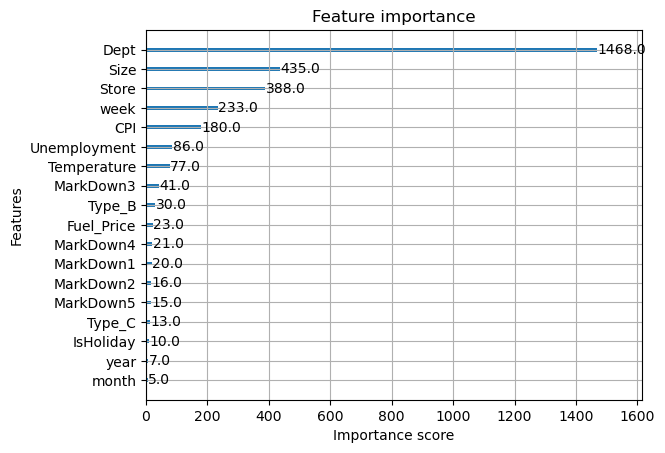

In [21]:
from xgboost import plot_importance

plot_importance(xgb_model)
plt.show()

In [24]:
error_df = pd.DataFrame({
    'Actual': y_val.values,
    'Predicted': y_pred_xgb,
    'Error': abs(y_val - y_pred_xgb),
    'Store': X_val['Store'].values   # ✅ ADD THIS
})

In [25]:
error_df.groupby('Store')['Error'].mean().sort_values(ascending=False).head()

Store
10    9016.837998
20    6717.957200
14    6403.250185
23    6072.972572
4     4775.954879
Name: Error, dtype: float64